##### Master Degree in Computer Science and Data Science for Economics and Health

# Tokenization approaches: linguistic vs. statistical

### Prof. Alfio Ferrara

## Introduction

In the previous notebook we saw that the unit we choose to build a numeric representation on is a trade-off: whole documents are too specific, single characters are too generic, and something in between, the **token**, is what we are looking for. We did not say how to obtain tokens. This notebook is about exactly that.

There are two broad families of approaches:

1. **Linguistic (rule-based) tokenization**: a set of hand-written rules, informed by what we know about a language, decides where a token starts and ends.
2. **Statistical tokenization**: the vocabulary of tokens is *learned* from a corpus, so that the units are the ones that make the corpus easier to represent (WordPiece, BPE).

We start with the first family.

## Linguistic tokenization

The idea is to encode in a procedure what a speaker of the language would consider a "word": sequences of letters separated by spaces, punctuation that is not part of a word, contractions such as *don't* that hide two words, and so on. Let's see how far different rule sets get us, using the tools available in [NLTK](https://www.nltk.org/api/nltk.tokenize.html).

### A test snippet

Real recipes contain many of the situations that make tokenization non-trivial: punctuation attached to words, contractions, measures, fractions, abbreviations, symbols. We take a snippet written in the style of the recipes in our dataset and we use it as a common test bench.

In [41]:
from nlp.utils import show

In [42]:
text = "Cream margarine and sugar until smooth. Don't overmix; grease a 9″ round cake pan and bake at 350ºF for 25 min. Use 2/3 cup olive oil, 3 T. sugar & mix (well)!"
show(text, width=60)

Cream margarine and sugar until smooth. Don't overmix;
grease a 9″ round cake pan and bake at 350ºF for 25 min. Use
2/3 cup olive oil, 3 T. sugar & mix (well)!


### Splitting on whitespace

The simplest possible rule: a token is a maximal sequence of non-space characters. In Python this is just `str.split`; NLTK exposes the same rule as `WhitespaceTokenizer`.

In [43]:
from nltk.tokenize import WhitespaceTokenizer

WhitespaceTokenizer().tokenize(text)

['Cream',
 'margarine',
 'and',
 'sugar',
 'until',
 'smooth.',
 "Don't",
 'overmix;',
 'grease',
 'a',
 '9″',
 'round',
 'cake',
 'pan',
 'and',
 'bake',
 'at',
 '350ºF',
 'for',
 '25',
 'min.',
 'Use',
 '2/3',
 'cup',
 'olive',
 'oil,',
 '3',
 'T.',
 'sugar',
 '&',
 'mix',
 '(well)!']

It is fast and predictable, but punctuation sticks to words: `smooth.`, `overmix;`, `oil,` and `(well)!` are different tokens from `smooth`, `overmix`, `oil` and `well`. In a vocabulary, the same word would be split into many different entries depending on what follows it.

### Regular expression tokenizers

A more flexible way to write rules is to describe tokens with a regular expression. `RegexpTokenizer` takes a pattern and, by default, returns everything that **matches** it (with `gaps=True` the pattern describes the separators instead).

Keeping only sequences of word characters (`\w+`) gets rid of punctuation:

In [44]:
from nltk.tokenize import RegexpTokenizer

RegexpTokenizer(r"\w+").tokenize(text)

['Cream',
 'margarine',
 'and',
 'sugar',
 'until',
 'smooth',
 'Don',
 't',
 'overmix',
 'grease',
 'a',
 '9',
 'round',
 'cake',
 'pan',
 'and',
 'bake',
 'at',
 '350ºF',
 'for',
 '25',
 'min',
 'Use',
 '2',
 '3',
 'cup',
 'olive',
 'oil',
 '3',
 'T',
 'sugar',
 'mix',
 'well']

Punctuation is gone, but so is a lot of information: `Don't` became `Don` and `t`, the fraction `2/3` became `2` and `3`, and `9″` lost its unit. The rule is too crude for these cases.

We can refine it by writing a pattern that reflects our idea of a token: words that may contain an internal apostrophe, numbers that may contain a slash or a decimal point, and any other single non-space symbol as a token on its own.

In [45]:
pattern = r"""(?x)                  # verbose mode
    \d+[./]\d+                    # decimals and fractions (2/3, 1.5), tried first
  | \w+(?:'\w+)?                  # words, with an optional internal apostrophe (don't)
  | [^\w\s]                      # any other single symbol
"""
RegexpTokenizer(pattern).tokenize(text)

['Cream',
 'margarine',
 'and',
 'sugar',
 'until',
 'smooth',
 '.',
 "Don't",
 'overmix',
 ';',
 'grease',
 'a',
 '9',
 '″',
 'round',
 'cake',
 'pan',
 'and',
 'bake',
 'at',
 '350ºF',
 'for',
 '25',
 'min',
 '.',
 'Use',
 '2/3',
 'cup',
 'olive',
 'oil',
 ',',
 '3',
 'T',
 '.',
 'sugar',
 '&',
 'mix',
 '(',
 'well',
 ')',
 '!']

Now `Don't`, `2/3` and `350ºF` are preserved, and punctuation is separated. But every rule we write is a decision, and a decision that works on some cases fails on others: `9″` is split into `9` and `″`, and `3 T.` loses the fact that `T.` is an abbreviation (it becomes `T` and `.`). Fixing these cases means adding more rules, and the order of the alternatives in the pattern matters (try moving the fraction alternative to the end and see what happens to `2/3`).

NLTK also ships some ready-made regular expression tokenizers. `WordPunctTokenizer` is the classic one: it separates sequences of alphanumeric characters from sequences of punctuation (`\w+|[^\w\s]+`).

In [46]:
from nltk.tokenize import WordPunctTokenizer

WordPunctTokenizer().tokenize(text)

['Cream',
 'margarine',
 'and',
 'sugar',
 'until',
 'smooth',
 '.',
 'Don',
 "'",
 't',
 'overmix',
 ';',
 'grease',
 'a',
 '9',
 '″',
 'round',
 'cake',
 'pan',
 'and',
 'bake',
 'at',
 '350ºF',
 'for',
 '25',
 'min',
 '.',
 'Use',
 '2',
 '/',
 '3',
 'cup',
 'olive',
 'oil',
 ',',
 '3',
 'T',
 '.',
 'sugar',
 '&',
 'mix',
 '(',
 'well',
 ')!']

It separates punctuation, but it breaks `Don't` into `Don`, `'`, `t` and `2/3` into `2`, `/`, `3`, and it also glues consecutive punctuation marks together (`)!`).

### The Treebank tokenizer

Instead of a single pattern, we can apply a *sequence* of rules that encode linguistic conventions. The `TreebankWordTokenizer` implements the tokenization conventions of the Penn Treebank, the annotated English corpus that, for decades, was the reference for NLP models. Among the conventions: contractions are split into their components (`don't` → `do` + `n't`), punctuation is separated from words, parentheses become their own tokens.

In [47]:
from nltk.tokenize import TreebankWordTokenizer

TreebankWordTokenizer().tokenize(text)

['Cream',
 'margarine',
 'and',
 'sugar',
 'until',
 'smooth.',
 'Do',
 "n't",
 'overmix',
 ';',
 'grease',
 'a',
 '9″',
 'round',
 'cake',
 'pan',
 'and',
 'bake',
 'at',
 '350ºF',
 'for',
 '25',
 'min.',
 'Use',
 '2/3',
 'cup',
 'olive',
 'oil',
 ',',
 '3',
 'T.',
 'sugar',
 '&',
 'mix',
 '(',
 'well',
 ')',
 '!']

`Don't` is now `Do` + `n't`, which is linguistically meaningful (the negation is a token of its own) and `(well)!` is split properly. But notice `smooth.` and `min.`: the Treebank tokenizer only separates a period at the **end of the text**, because it assumes that the text has already been split into sentences. This is why, in practice, we do not use it alone.

### Sentence splitting and `word_tokenize`

A period can end a sentence (`smooth.`) or be part of a token (`T.`, `3.5`, `e.g.`). Deciding which is the job of a **sentence tokenizer**. NLTK's `sent_tokenize` uses Punkt, an unsupervised model trained to detect abbreviations and sentence boundaries.

In [48]:
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(text)
for s in sentences:
    print(s)

Cream margarine and sugar until smooth.
Don't overmix; grease a 9″ round cake pan and bake at 350ºF for 25 min.
Use 2/3 cup olive oil, 3 T. sugar & mix (well)!


`word_tokenize` combines the two steps: it first splits the text into sentences with Punkt, then it applies a Treebank-style tokenizer to each sentence. It is the default choice for English text in NLTK.

In [49]:
from nltk.tokenize import word_tokenize

word_tokenize(text)

['Cream',
 'margarine',
 'and',
 'sugar',
 'until',
 'smooth',
 '.',
 'Do',
 "n't",
 'overmix',
 ';',
 'grease',
 'a',
 '9″',
 'round',
 'cake',
 'pan',
 'and',
 'bake',
 'at',
 '350ºF',
 'for',
 '25',
 'min',
 '.',
 'Use',
 '2/3',
 'cup',
 'olive',
 'oil',
 ',',
 '3',
 'T.',
 'sugar',
 '&',
 'mix',
 '(',
 'well',
 ')',
 '!']

Now `smooth`, `min` and the final period are handled correctly and `Do` + `n't` is kept. Some decisions remain debatable, though: `T.` is kept as an abbreviation (good), while `9″`, `350ºF` and `2/3` are left as single tokens, which may or may not be what we want depending on the task.

### Domain-specific tokenizers

Rules encode assumptions about the text. When the text is different from the *clean edited prose* that the Treebank conventions were designed for, a different rule set is needed. `TweetTokenizer` is built for social media text: it keeps contractions together, and it recognizes emoticons, hashtags and mentions as single tokens.

In [50]:
from nltk.tokenize import TweetTokenizer

tweet = "OMG this #carbonara is sooooo good :-) thanks @chef_anna!!! can't wait to cook it again <3"

print("word_tokenize :", word_tokenize(tweet))
print("TweetTokenizer:", TweetTokenizer().tokenize(tweet))

word_tokenize : ['OMG', 'this', '#', 'carbonara', 'is', 'sooooo', 'good', ':', '-', ')', 'thanks', '@', 'chef_anna', '!', '!', '!', 'ca', "n't", 'wait', 'to', 'cook', 'it', 'again', '<', '3']
TweetTokenizer: ['OMG', 'this', '#carbonara', 'is', 'sooooo', 'good', ':-)', 'thanks', '@chef_anna', '!', '!', '!', "can't", 'wait', 'to', 'cook', 'it', 'again', '<3']


The Treebank rules destroy the hashtag, the mention and the emoticons. Options of `TweetTokenizer` such as `preserve_case=False`, `reduce_len=True` (`sooooo` → `sooo`) or `strip_handles=True` show how a rule-based tokenizer is a collection of decisions that can be switched on and off.

In [51]:
TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=True).tokenize(tweet)

['omg',
 'this',
 '#carbonara',
 'is',
 'sooo',
 'good',
 ':-)',
 'thanks',
 '!',
 '!',
 '!',
 "can't",
 'wait',
 'to',
 'cook',
 'it',
 'again',
 '<3']

### Multi-word expressions

So far, all tokenizers split text into units that are *shorter* than or equal to a word. Sometimes, however, the meaningful unit is a **multi-word expression**: `olive oil` is not "a kind of oil that is olive", it is a specific ingredient. `MWETokenizer` post-processes an already tokenized text and merges the sequences that we list in a lexicon.

In [52]:
from nltk.tokenize import MWETokenizer

mwe = MWETokenizer([("olive", "oil"), ("baking", "powder"), ("brown", "sugar")], separator="_")
mwe.tokenize(word_tokenize("Mix baking powder and brown sugar, then add 2 tbsp of olive oil."))

['Mix',
 'baking_powder',
 'and',
 'brown_sugar',
 ',',
 'then',
 'add',
 '2',
 'tbsp',
 'of',
 'olive_oil',
 '.']

Note that here the rule is not a matter of characters but of a **lexicon**: somebody has to write down the list of expressions, and any expression that is not in the list is missed.

### Comparing the tokenizers

Let's put the outputs side by side on the same snippet.

In [53]:
import pandas as pd

tokenizers = {
    "whitespace": WhitespaceTokenizer().tokenize,
    "regexp \\w+": RegexpTokenizer(r"\w+").tokenize,
    "wordpunct": WordPunctTokenizer().tokenize,
    "treebank": TreebankWordTokenizer().tokenize,
    "word_tokenize": word_tokenize,
    "tweet": TweetTokenizer().tokenize,
}

results = {name: tok(text) for name, tok in tokenizers.items()}
pd.DataFrame({"n_tokens": {k: len(v) for k, v in results.items()},
              "n_types": {k: len(set(v)) for k, v in results.items()}})

,n_tokens,n_types
whitespace,32,30
regexp \w+,33,30
wordpunct,44,39
treebank,38,36
word_tokenize,40,37
tweet,41,37


In [54]:
cases = ["smooth", "smooth.", "Don't", "Don", "n't", "2/3", "9″", "350ºF", "T.", "(well)!"]
pd.DataFrame({name: [c in toks for c in cases] for name, toks in results.items()}, index=cases)

,whitespace,regexp \w+,wordpunct,treebank,word_tokenize,tweet
smooth,False,True,True,False,True,True
smooth.,True,False,False,True,False,False
Don't,True,False,False,False,False,True
Don,False,True,True,False,False,False
n't,False,False,False,True,True,False
2/3,True,False,False,True,True,True
9″,True,False,False,True,True,False
350ºF,True,True,True,True,True,True
T.,True,False,False,True,True,False
(well)!,True,False,False,False,False,False


The table tells, for each tokenizer, which of the candidate tokens appear in the output. There is no tokenizer that is right on all cases: each one embodies a different set of assumptions.

### Take-away

Rule-based tokenization is transparent and deterministic: we know exactly why a token has been produced, and the rules can be tuned to the domain. Its weaknesses are also evident:

- the rules are **language- and domain-specific**: Treebank conventions for English do not work for Italian (`l'albero`), German (compound words) or Chinese (no spaces at all)
- every unusual string (`350ºF`, `2/3`, `9″`) requires a new rule, and rules interact in unexpected ways
- the result is still a **closed vocabulary of words**: a word that we did not see when we built the vocabulary is simply unknown

In the next section we look at spaCy, which goes one step further by using linguistic knowledge that is not just about characters.

## Linguistic tokenization with spaCy

[spaCy](https://spacy.io/) is a library for NLP built around the idea of a **pipeline**: a text goes through a sequence of components, and the first one is the tokenizer. Like the NLTK tokenizers, spaCy's tokenizer is rule-based: language-specific rules decide where the tokens are. The difference is in what we get back. NLTK returns a list of strings; spaCy returns a rich object in which every token still *knows* about the text it comes from.

We load an English pipeline and we process the same test snippet we used with NLTK.

In [55]:
import spacy

nlp = spacy.load("en_core_web_lg")
doc = nlp(text)
doc

Cream margarine and sugar until smooth. Don't overmix; grease a 9″ round cake pan and bake at 350ºF for 25 min. Use 2/3 cup olive oil, 3 T. sugar & mix (well)!

### Doc and Token

The result of `nlp(text)` is a `Doc`: a sequence of `Token` objects. We can iterate over it, index it, and slice it (a slice is a `Span`).

In [56]:
print(type(doc), type(doc[1]), type(doc[1:4]))
print(len(doc), "tokens")
show([token.text for token in doc], width=60)

<class 'spacy.tokens.doc.Doc'> <class 'spacy.tokens.token.Token'> <class 'spacy.tokens.span.Span'>
40 tokens
['Cream', 'margarine', 'and', 'sugar', 'until', 'smooth',
 '.', 'Do', "n't", 'overmix', ';', 'grease', 'a', '9″',
 'round', 'cake', 'pan', 'and', 'bake', 'at', '350ºF',
 'for', '25', 'min', '.', 'Use', '2/3', 'cup', 'olive',
 'oil', ',', '3', 'T.', 'sugar', '&', 'mix', '(', 'well',
 ')', '!']


On this snippet, spaCy's tokens are exactly the ones produced by NLTK's `word_tokenize`:

In [57]:
from nltk.tokenize import word_tokenize

[token.text for token in doc] == word_tokenize(text)

True

The two tools reach the same result with similar conventions (the contraction `Don't` is split into `Do` + `n't`, punctuation is separated, `T.` is kept as an abbreviation). The interesting differences are in what a spaCy token contains.

### What is inside a token

A `Token` is not a string, it is a bundle of information. We can group it into three kinds.

**1. Where the token comes from.** Every token records its position in the original text (`idx`) and whether it was followed by a space (`whitespace_`). As a consequence, spaCy tokenization is *non-destructive*: from the tokens we can rebuild the original text exactly, something that is not possible with a list of strings in which spaces have been thrown away.

In [58]:
print([(t.text, t.idx, t.whitespace_) for t in doc[5:10]])
print()
print("Original text rebuilt from tokens:", "".join(t.text_with_ws for t in doc) == text)
print("Each token aligned to the text:", all(text[t.idx:t.idx + len(t)] == t.text for t in doc))

[('smooth', 32, ''), ('.', 38, ' '), ('Do', 40, ''), ("n't", 42, ' '), ('overmix', 46, '')]

Original text rebuilt from tokens: True
Each token aligned to the text: True


**2. What the token looks like.** Tokens expose simple lexical properties, computed from the string: its lowercase form, its shape (`X` for uppercase letters, `x` for lowercase, `d` for digits), and flags such as `is_alpha`, `is_punct`, `like_num`.

In [59]:
import pandas as pd

def surface(tokens):
    return pd.DataFrame([{
        "text": t.text, "lower": t.lower_, "shape": t.shape_,
        "is_alpha": t.is_alpha, "is_punct": t.is_punct, "like_num": t.like_num,
    } for t in tokens])

surface([t for t in doc if t.text in ("Cream", "smooth", ".", "n't", "9″", "350ºF", "25", "2/3", "T.", "(")])

,text,lower,shape,is_alpha,is_punct,like_num
0,Cream,cream,Xxxxx,True,False,False
1,smooth,smooth,xxxx,True,False,False
2,.,.,.,False,True,False
3,n't,n't,x'x,False,False,False
4,9″,9″,d″,False,False,False
5,350ºF,350ºf,dddxX,False,False,False
6,25,25,dd,False,False,True
7,.,.,.,False,True,False
8,2/3,2/3,d/d,False,False,True
9,T.,t.,X.,False,False,False


**3. What the token means in the sentence.** The remaining attributes are not computed from the string alone: they are predicted by the other components of the pipeline, which are statistical models trained on annotated corpora. They describe the morphological and syntactic role of the token:

- `lemma_`: the base form (`n't` → `not`)
- `pos_` and `tag_`: the part of speech, coarse (universal tags such as `NOUN`, `VERB`) and fine-grained (Penn Treebank tags such as `NN`, `VB`)
- `morph`: morphological features (tense, number, polarity...)
- `dep_` and `head`: the syntactic dependency that links the token to its head in the sentence

In [60]:
print("Pipeline components:")
show(nlp.pipe_names)

Pipeline components:
['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [61]:
def linguistic(tokens):
    return pd.DataFrame([{
        "text": t.text, "lemma": t.lemma_, "pos": t.pos_, "tag": t.tag_,
        "morph": str(t.morph), "dep": t.dep_, "head": t.head.text,
    } for t in tokens])

linguistic(list(doc)[7:19])

,text,lemma,pos,tag,morph,dep,head
0,Do,do,AUX,VB,VerbForm=Inf,aux,overmix
1,n't,not,PART,RB,Polarity=Neg,neg,overmix
2,overmix,overmix,VERB,VB,VerbForm=Inf,ccomp,grease
3,;,;,PUNCT,:,,punct,grease
4,grease,grease,VERB,VB,VerbForm=Inf,ROOT,grease
5,a,a,DET,DT,Definite=Ind|PronType=Art,det,pan
6,9″,9″,NUM,CD,NumType=Card,nummod,pan
7,round,round,NOUN,NN,Number=Sing,compound,pan
8,cake,cake,NOUN,NN,Number=Sing,compound,pan
9,pan,pan,NOUN,NN,Number=Sing,dobj,grease


Note that even the notion of sentence is provided by the pipeline: `doc.sents` uses the syntactic analysis to decide where a sentence ends, instead of a separate model like Punkt. Since it is a statistical prediction, it can differ from Punkt: on our snippet it finds two sentences, while Punkt found three (it does not split after `min.`).

In [62]:
for sent in doc.sents:
    show(sent.text, width=60)
    print("-------")

Cream margarine and sugar until smooth.
-------
Don't overmix; grease a 9″ round cake pan and bake at 350ºF
for 25 min. Use 2/3 cup olive oil, 3 T. sugar & mix (well)!
-------


### Customizing the tokenizer

How does spaCy decide where to split? The tokenizer first splits the text on whitespace, then it processes each chunk with a set of language-specific rules:

- **special cases** (exceptions): strings that must be tokenized in a fixed way (`don't` → `do`, `n't`)
- **prefixes** and **suffixes**: characters to be detached from the beginning and the end of a chunk (quotes, brackets, final punctuation)
- **infixes**: characters that split a chunk in the middle (hyphens between letters, for example)

The `explain` method shows which rule produced each token. We use it on a new snippet with units of measure that are typical of recipes. To modify the rules without altering the pipeline above, we work on a lightweight English pipeline that has only the tokenizer (`spacy.blank`).

In [63]:
snippet = "Add 2 tbsp. of olive oil, 3 tsp. salt and bake at 350ºF for 9″ cakes."

blank = spacy.blank("en")
show([t.text for t in blank.tokenizer(snippet)], width=60)
print()
show(blank.tokenizer.explain(snippet), width=60)

['Add', '2', 'tbsp', '.', 'of', 'olive', 'oil', ',', '3',
 'tsp', '.', 'salt', 'and', 'bake', 'at', '350ºF', 'for',
 '9″', 'cakes', '.']

[('TOKEN', 'Add'), ('TOKEN', '2'), ('TOKEN', 'tbsp'),
 ('SUFFIX', '.'), ('TOKEN', 'of'), ('TOKEN', 'olive'),
 ('TOKEN', 'oil'), ('SUFFIX', ','), ('TOKEN', '3'),
 ('TOKEN', 'tsp'), ('SUFFIX', '.'), ('TOKEN', 'salt'),
 ('TOKEN', 'and'), ('TOKEN', 'bake'), ('TOKEN', 'at'),
 ('TOKEN', '350ºF'), ('TOKEN', 'for'), ('TOKEN', '9″'),
 ('TOKEN', 'cakes'), ('SUFFIX', '.')]


The abbreviations `tbsp.` and `tsp.` are broken (the final period is treated as a suffix, i.e. as punctuation), and `350ºF` and `9″` are single tokens in which the number and the unit are glued together. We can change this behavior with our own rules. First, special cases:

In [64]:
blank.tokenizer.add_special_case("tbsp.", [{"ORTH": "tbsp."}])
blank.tokenizer.add_special_case("tsp.", [{"ORTH": "tsp."}])

show([t.text for t in blank.tokenizer(snippet)], width=60)

['Add', '2', 'tbsp.', 'of', 'olive', 'oil', ',', '3',
 'tsp.', 'salt', 'and', 'bake', 'at', '350ºF', 'for', '9″',
 'cakes', '.']


Then an infix rule, to separate a number from the unit that follows it. An infix is a regular expression: here, a position (an empty match) between a digit and one of the characters `º`, `″` or a letter.

In [65]:
from spacy.util import compile_infix_regex

infixes = list(blank.Defaults.infixes) + [r"(?<=[0-9])(?=[ºa-zA-Z″])"]
blank.tokenizer.infix_finditer = compile_infix_regex(infixes).finditer

show([t.text for t in blank.tokenizer(snippet)], width=60)

['Add', '2', 'tbsp.', 'of', 'olive', 'oil', ',', '3',
 'tsp.', 'salt', 'and', 'bake', 'at', '350', 'ºF', 'for',
 '9', '″', 'cakes', '.']


Special cases can also contain more than one word, which makes them the spaCy counterpart of NLTK's `MWETokenizer`: a lexicon of expressions that must be kept together.

In [66]:
blank.tokenizer.add_special_case("olive oil", [{"ORTH": "olive oil"}])

show([t.text for t in blank.tokenizer(snippet)], width=60)

['Add', '2', 'tbsp.', 'of', 'olive oil', ',', '3', 'tsp.',
 'salt', 'and', 'bake', 'at', '350', 'ºF', 'for', '9', '″',
 'cakes', '.']


As with NLTK, this is a matter of writing rules and lexicons by hand, but here the rules are organized in a clear structure that we can inspect and extend, without replacing the whole tokenizer.

### Tokenization depends on the language

The rules of a tokenizer are specific to a language. Let's try an Italian recipe sentence with three tools: the NLTK `word_tokenize` (with the language set to Italian), the English spaCy tokenizer and the Italian spaCy pipeline.

In [67]:
nlp_it = spacy.load("it_core_news_lg")

sentence_it = "Aggiungere l'olio d'oliva dell'ultima ricetta e un po' di sale, poi l'albero di Natale."

show({
    "nltk (italian)": word_tokenize(sentence_it, language="italian"),
    "spacy en": [t.text for t in nlp.tokenizer(sentence_it)],
    "spacy it": [t.text for t in nlp_it.tokenizer(sentence_it)],
}, width=70)

{'nltk (italian)': ['Aggiungere', "l'olio", "d'oliva", "dell'ultima",
                    'ricetta', 'e', 'un', 'po', "'", 'di', 'sale',
                    ',', 'poi', "l'albero", 'di', 'Natale', '.'],
 'spacy en': ['Aggiungere', "l'olio", "d'oliva", "dell'ultima",
              'ricetta', 'e', 'un', 'po', "'", 'di', 'sale', ',',
              'poi', "l'albero", 'di', 'Natale', '.'],
 'spacy it': ['Aggiungere', "l'", 'olio', "d'", 'oliva', "dell'",
              'ultima', 'ricetta', 'e', 'un', "po'", 'di', 'sale',
              ',', 'poi', "l'", 'albero', 'di', 'Natale', '.']}


In NLTK the `language` argument only affects the sentence splitter (Punkt): the word-level rules remain the English Treebank ones, so `l'olio`, `d'oliva` and `dell'ultima` are single tokens and `po'` is broken in two. The English spaCy tokenizer behaves in the same way. The Italian pipeline knows that the elided article is a separate word (`l'` + `olio`, `dell'` + `ultima`) and that `po'` is a token (a truncation of *poco*).

### Take-away

spaCy tokenization follows the same paradigm as NLTK: hand-written rules and lexicons, organized per language. What it adds is a token that keeps track of the original text, carries information beyond its string and can be customized rule by rule. The limits are the same, though: a rule set for each language, new rules for every unusual string, and a vocabulary of tokens that is closed on the words that the rules and the lexicons can recognize.

## Statistical tokenization

Rule-based tokenizers give us tokens that make sense to a speaker of the language, but they leave us with a vocabulary that we do not control. Before introducing the alternative, let's look at this problem on our data.

### The vocabulary of a rule-based tokenizer

We take the instructions of the recipes, we keep 80% of them as a *training* set from which we build the vocabulary, and the remaining 20% as a *test* set of texts that the tokenizer has never seen. We tokenize with `word_tokenize` after lowercasing.

In [68]:
import json
import random

with open("/Users/Flint/Data/recipes/foodcom/subsets/recipes_cuisine_tipo_10k.json") as f:
    recipes = json.load(f)

texts = [r["instructions"] for r in recipes if r["instructions"]]
random.seed(0)
random.shuffle(texts)
split = int(0.8 * len(texts))
train, test = texts[:split], texts[split:]

train_tokens = [word_tokenize(t.lower()) for t in train]
test_tokens = [word_tokenize(t.lower()) for t in test]

print(f"{len(train)} training recipes, {len(test)} test recipes")

7960 training recipes, 1991 test recipes


In [69]:
from collections import Counter

counts = Counter(w for doc in train_tokens for w in doc)
test_flat = [w for doc in test_tokens for w in doc]
oov = [w for w in test_flat if w not in counts]
hapax = sum(1 for c in counts.values() if c == 1)

print(f"Training tokens: {sum(counts.values())}")
print(f"Vocabulary size (distinct tokens): {len(counts)}")
print(f"Distinct tokens that occur only once: {hapax} ({hapax / len(counts):.0%})")
print()
print(f"Test tokens not in the vocabulary: {len(oov)} ({len(oov) / len(test_flat):.2%} of all test tokens)")
print(f"Distinct test tokens not in the vocabulary: {len(set(oov))} ({len(set(oov)) / len(set(test_flat)):.0%} of the distinct test tokens)")

Training tokens: 1007008
Vocabulary size (distinct tokens): 13222
Distinct tokens that occur only once: 6378 (48%)

Test tokens not in the vocabulary: 1916 (0.76% of all test tokens)
Distinct test tokens not in the vocabulary: 1651 (25% of the distinct test tokens)


Almost half of the vocabulary is made of tokens that occur once in a million: the vocabulary is dominated by very rare tokens. When we move to new texts, only a small fraction of the *occurrences* is unknown, but one out of four *distinct* tokens is a token that the vocabulary has never seen. Let's see what they look like.

In [70]:
random.seed(1)
show(sorted(random.sample(sorted(set(oov)), 30)), width=80)

["'keep", '12inch', '2x', '8-oz', 'approx.1cm/half', 'ball-size', 'coiple',
 'coy', 'desiring', 'don´t', 'inn', 'jauntily', 'luis', 'materials', 'med-heat',
 'mixture/egg', 'nerves', 'nows', 'prob', 'rollerskate', 'skiller', 'subgum',
 'thick-', 'w/buttered', 'w/mayo', 'w/oven', 'walkerswood', 'x10', '´cake´',
 'º']


They are a mix of rare words and names (`subgum`, `walkerswood`), misspellings (`coiple`, `skiller`), compounds and abbreviations (`ball-size`, `w/mayo`), numbers with units (`12inch`, `8-oz`) and unusual punctuation (`don´t`). No rule can foresee all of them.

The vocabulary does not stop growing as we read more text: there is always another rare word or another typo waiting.

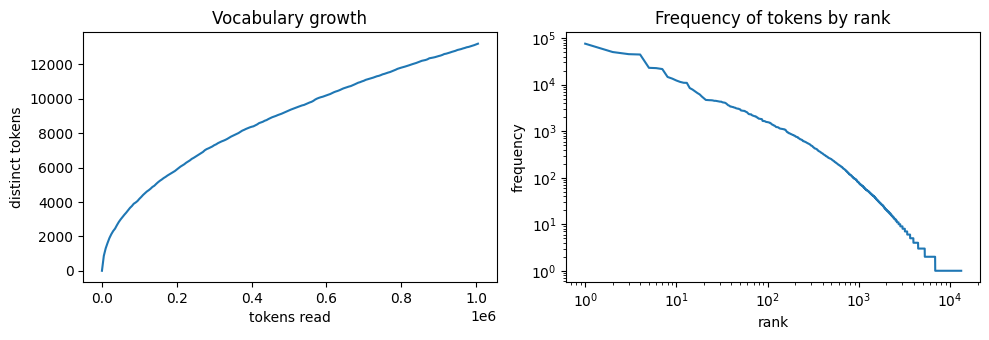

In [71]:
import numpy as np
import matplotlib.pyplot as plt

step = 5000
seen, growth = set(), []
for i, w in enumerate(w for doc in train_tokens for w in doc):
    seen.add(w)
    if i % step == 0:
        growth.append(len(seen))

freqs = sorted(counts.values(), reverse=True)

fig, ax = plt.subplots(ncols=2, figsize=(10, 3.5))
ax[0].plot(np.arange(len(growth)) * step, growth)
ax[0].set_title("Vocabulary growth")
ax[0].set_xlabel("tokens read")
ax[0].set_ylabel("distinct tokens")
ax[1].loglog(range(1, len(freqs) + 1), freqs)
ax[1].set_title("Frequency of tokens by rank")
ax[1].set_xlabel("rank")
ax[1].set_ylabel("frequency")
plt.tight_layout()
plt.show()

The left plot shows the growth of the vocabulary with the amount of text; the right plot shows that a handful of tokens are extremely frequent while most of them are in a long tail of very rare ones.

The usual way to keep the vocabulary under control is to cut the tail: we keep only the tokens that occur at least $k$ times and we replace all the others with a special *unknown* token.

In [72]:
rows = []
for min_count in (1, 2, 5, 10, 50):
    vocab = {w for w, c in counts.items() if c >= min_count}
    unknown = sum(1 for w in test_flat if w not in vocab)
    rows.append({"min count": min_count,
                 "vocabulary size": len(vocab),
                 "unknown test tokens": f"{unknown / len(test_flat):.2%}"})
pd.DataFrame(rows)

,min count,vocabulary size,unknown test tokens
0,1,13222,0.76%
1,2,6844,1.05%
2,5,3950,1.64%
3,10,2839,2.32%
4,50,1290,5.70%


We can shrink the vocabulary, but we pay for it: the more we cut, the more text is replaced by a token that carries no information at all. All the different rare words become the *same* token, the same kind of collapse that we saw with characters.

### The statistical idea

What if, instead of deciding in advance what a token is, we let the corpus decide? The idea of statistical tokenization is:

- start from a small alphabet of basic symbols (for example characters), so that any text can be written;
- let the **frequent** sequences of symbols become tokens on their own: the most common words end up as single tokens;
- write the **rare** sequences as a concatenation of smaller pieces (*subwords*) that are frequent because they occur in many different words;
- fix the **size of the vocabulary** beforehand: the procedure keeps adding tokens until the vocabulary has the desired size.

How the tokens are chosen is what BPE and WordPiece do, and we will see it in detail in the next section. For now, let's look at the result on a pretrained tokenizer: [BERT](https://huggingface.co/bert-base-uncased) uses WordPiece, with a vocabulary learned on a general English corpus (not on recipes). The `##` prefix marks a piece that continues the previous one.

In [73]:
from transformers import AutoTokenizer
from transformers.utils import logging

logging.set_verbosity_error()
wordpiece = AutoTokenizer.from_pretrained("bert-base-uncased")

words = ["oil", "sugar", "margarine", "colanders", "paprikash", "califlower", "unsweetened", "tbsp"]
show({w: wordpiece.tokenize(w) for w in words}, width=80)

{'califlower': ['cal', '##if', '##lowe', '##r'],
 'colanders': ['cola', '##nder', '##s'],
 'margarine': ['mar', '##gar', '##ine'],
 'oil': ['oil'],
 'paprikash': ['pa', '##pr', '##ika', '##sh'],
 'sugar': ['sugar'],
 'tbsp': ['tbs', '##p'],
 'unsweetened': ['un', '##sw', '##eet', '##ened']}


Frequent words (`oil`, `sugar`) are single tokens. Words that are rare or unseen are written as a sequence of pieces, and no word is *unknown*: `paprikash` and even the misspelled `califlower` can be represented. Note that the pieces are *statistically* frequent strings, not necessarily meaningful units: `colanders` is `cola` + `##nder` + `##s`. And since this vocabulary was not learned on recipes, some cooking words are split more than we would like (`tbsp`).

The same happens on running text:

In [74]:
show(wordpiece.tokenize(text), width=80)

['cream', 'mar', '##gar', '##ine', 'and', 'sugar', 'until', 'smooth', '.',
 'don', "'", 't', 'over', '##mi', '##x', ';', 'grease', 'a', '9', '″', 'round',
 'cake', 'pan', 'and', 'ba', '##ke', 'at', '350', '##º', '##f', 'for', '25',
 'min', '.', 'use', '2', '/', '3', 'cup', 'olive', 'oil', ',', '3', 't', '.',
 'sugar', '&', 'mix', '(', 'well', ')', '!']


### Advantages

**1. Control over the size of the vocabulary.** The size is a parameter of the method, chosen according to the needs of the model that will use the tokens. For example, BERT uses a vocabulary of about 30 thousand tokens, GPT-2 of about 50 thousand.

In [75]:
bpe = AutoTokenizer.from_pretrained("gpt2")

print(f"BERT (WordPiece) vocabulary size: {wordpiece.vocab_size}")
print(f"GPT-2 (BPE) vocabulary size:      {bpe.vocab_size}")

BERT (WordPiece) vocabulary size: 30522
GPT-2 (BPE) vocabulary size:      50257


This is the way out of the trade-off that we found in the first notebook. With characters we get a tiny vocabulary but very long sequences of tokens; with words we get short sequences but a huge, open-ended vocabulary. Let's see the two extremes on our data.

In [76]:
char_vocab = {c for t in train for c in t}

pd.DataFrame({
    "vocabulary size": [len(char_vocab), len(counts)],
    "tokens per recipe": [np.mean([len(t) for t in test]), np.mean([len(d) for d in test_tokens])],
}, index=["characters", "words (rule-based)"]).round(1)

,vocabulary size,tokens per recipe
characters,138,606.4
words (rule-based),13222,127.0


A statistical tokenizer lets us choose *where* to stand between these two extremes, by choosing the size of the vocabulary. We will measure this effect when we train our own tokenizer.

**2. No unknown words.** Since any text can be written with the basic symbols, the tokenizer does not need an unknown token for words. The only limit is the alphabet: BERT's alphabet is finite, and a character that is not in it makes the *whole* word unknown. Let's look for the words of our test set in this situation.

In [77]:
test_words = {w for doc in test_tokens for w in doc}
unknown = sorted(w for w in test_words if wordpiece.unk_token in wordpiece.tokenize(w))
show(unknown)

['400˚f/200˚c']


It is a pair of temperatures written with a symbol that looks like the degree sign but is a different character (`˚`), which is not in the BERT alphabet. The variants of BPE that work on **bytes** instead of characters, such as GPT-2, close this gap: every string is a sequence of bytes, so every string can be tokenized. Here the unusual symbol is written as its bytes (displayed through a byte-to-character convention of GPT-2, hence the strange characters).

In [78]:
show({w: bpe.tokenize(w) for w in unknown})

{'400˚f/200˚c': ['400', 'Ë', 'ļ', 'f', '/', '200', 'Ë', 'ļ', 'c']}


**3. Independence from the language and the domain.** The procedure does not contain any rule about a language. If we learn the vocabulary from an Italian corpus, we obtain Italian tokens. Compare the English BERT vocabulary with an Italian one on the sentence we used with spaCy:

In [79]:
italian_wordpiece = AutoTokenizer.from_pretrained("dbmdz/bert-base-italian-uncased")

show({
    "english vocabulary": wordpiece.tokenize(sentence_it),
    "italian vocabulary": italian_wordpiece.tokenize(sentence_it),
}, width=80)

{'english vocabulary': ['ag', '##gi', '##ung', '##ere', 'l', "'", 'ol', '##io',
                        'd', "'", 'ol', '##iva', 'dell', "'", 'ul', '##ti',
                        '##ma', 'rice', '##tta', 'e', 'un', 'po', "'", 'di',
                        'sale', ',', 'po', '##i', 'l', "'", 'al', '##ber',
                        '##o', 'di', 'natal', '##e', '.'],
 'italian vocabulary': ['aggiungere', 'l', "'", 'olio', 'd', "'", 'oliva',
                        'dell', "'", 'ultima', 'ricetta', 'e', 'un', 'po', "'",
                        'di', 'sale', ',', 'poi', 'l', "'", 'albero', 'di',
                        'natale', '.']}


It is the same method, applied to a different corpus. Where the English vocabulary breaks `aggiungere` and `olio` into pieces, the Italian one has them as single tokens. The same holds for the domain: a vocabulary learned on recipes can have `tbsp` or `paprikash` as tokens, while a vocabulary learned on newspapers will hardly have them.

**4. Compact representation of frequent words, sharing of pieces among rare ones.** Frequent words cost one token; rare words are decomposed in pieces that occur in other words, so that pieces such as `un` and `##ened`, which occur in many words, are shared among them.

The remaining question is how to actually obtain such a vocabulary from a corpus. This is what Byte-Pair Encoding and WordPiece do.

## Learning the vocabulary: BPE and WordPiece

Both algorithms build the vocabulary **bottom-up**. They start from the smallest units (characters), and at each iteration they *merge* two units that occur next to each other into a new, longer unit, until the vocabulary reaches the size that we asked for. They differ in how they choose the pair to merge and in how they tokenize new text.

### Working on words

Both methods work on a corpus that has already been split into words with a simple rule (for example on whitespace and punctuation): merges happen **inside** a word and never across two words. What we need from the corpus is just the list of distinct words and how many times each one occurs.

### Byte-Pair Encoding (BPE)

BPE was born as a data compression algorithm (Gage, 1994), that replaces the most frequent pair of adjacent bytes with a new symbol, and it was adapted to build subword vocabularies for machine translation by Sennrich, Haddow and Birch (2016).

**Training**

1. Split the corpus into words and count the frequency of each word.
2. Initialize the vocabulary with all the characters that appear in the corpus, and write every word as a sequence of characters.
3. Count all the pairs of adjacent symbols, over all the words, weighting each pair by the frequency of the word in which it occurs.
4. Take the **most frequent** pair, add the concatenation of its two symbols to the vocabulary, and replace the pair with the new symbol everywhere. We record this *merge rule*.
5. Repeat steps 3 and 4 until the vocabulary has reached the desired size $V$. The number of merges is therefore $V$ minus the size of the initial alphabet: this is how we control the size of the vocabulary.

**Tokenizing a new word**

Split the word into characters and apply the merge rules **in the same order in which they were learned**.

Two remarks. The original BPE also adds an end-of-word symbol to every word, so that a piece at the end of a word (`er`) can be distinguished from the same piece inside a word: we do not use it in our example, to keep it simple. The byte-level variant seen in the previous section (GPT-2) starts from the 256 possible bytes instead of the characters, so that any text can be encoded.

### WordPiece

WordPiece was developed at Google for voice search (Schuster and Nakajima, 2012) and it is the tokenizer of BERT. The training loop is the same as BPE, with three differences.

(1) **Notation.** Every symbol that does not start a word is marked with the prefix `##`: `baking` is initially written `b ##a ##k ##i ##n ##g`. When two symbols are merged the prefix of the second one is dropped (`##i` + `##n` gives `##in`).

(2) **Choice of the pair.** BPE picks the most *frequent* pair. WordPiece picks the pair with the highest **score**

$$\text{score}(a, b) = \frac{\text{freq}(ab)}{\text{freq}(a) \times \text{freq}(b)}$$

where $\text{freq}(ab)$ is the number of times $a$ and $b$ occur next to each other and $\text{freq}(a)$, $\text{freq}(b)$ are the number of occurrences of each symbol in the corpus (in the current segmentation). The score is high when $a$ and $b$ occur together much more often than we would expect if they were independent: it favors pairs whose members are *rarely found apart*, even if the pair is not very frequent. This is a criterion related to the likelihood of the training corpus: the merge that we choose is the one that increases it the most.

(3) **Tokenizing a new word.** WordPiece does not replay the merges. It uses the vocabulary only, and finds the **longest** token in the vocabulary that matches the beginning of the word, then the longest one that matches what remains (marked with `##`), and so on. If at some point no token matches, the whole word is replaced by the unknown token.

In summary:

| | BPE | WordPiece |
|---|---|---|
| Which pair is merged | the most frequent | the one with the highest score $\frac{\text{freq}(ab)}{\text{freq}(a)\,\text{freq}(b)}$ |
| Continuation of a word | no marker (in our example) | prefix `##` |
| New word | replay the merges in order | longest match from the left |
| Used by | GPT-2 and many other language models | BERT |

### A small example

We work with this corpus, that is already split into words. The number is the frequency of each word.

| word | frequency |
|---|---|
| `bake` | 4 |
| `baked` | 3 |
| `baking` | 2 |
| `cake` | 3 |
| `cakes` | 2 |

The alphabet is made of 10 characters: `a`, `b`, `c`, `d`, `e`, `g`, `i`, `k`, `n`, `s`.

We run the training for **4 merges**, so that the final vocabulary has 14 tokens. We will do it twice, with BPE and with WordPiece.

If two pairs have the same frequency (BPE) or the same score (WordPiece), we take the one that comes first while reading the words of the table above from left to right.

#### BPE

**Step 0: initialization.** Every word is a sequence of characters, and the vocabulary is the alphabet.

- `bake`: `b · a · k · e`
- `baked`: `b · a · k · e · d`
- `baking`: `b · a · k · i · n · g`
- `cake`: `c · a · k · e`
- `cakes`: `c · a · k · e · s`

**Step 1.** All the pairs, counted over all the words and weighted by the frequency of the words:

| pair | count |
|---|---|
| `a` + `k` | 14 |
| `k` + `e` | 12 |
| `b` + `a` | 9 |
| `c` + `a` | 5 |
| `e` + `d` | 3 |
| `k` + `i` | 2 |
| `i` + `n` | 2 |
| `n` + `g` | 2 |
| `e` + `s` | 2 |

The most frequent pair is `a` + `k` (14 times): we add `ak` to the vocabulary and we merge the pair everywhere.

- `bake`: `b · ak · e`
- `baked`: `b · ak · e · d`
- `baking`: `b · ak · i · n · g`
- `cake`: `c · ak · e`
- `cakes`: `c · ak · e · s`

**Step 2.** The four most frequent pairs:

| pair | count |
|---|---|
| `ak` + `e` | 12 |
| `b` + `ak` | 9 |
| `c` + `ak` | 5 |
| `e` + `d` | 3 |

The most frequent pair is `ak` + `e` (12 times): we add `ake` to the vocabulary and we merge the pair everywhere.

- `bake`: `b · ake`
- `baked`: `b · ake · d`
- `baking`: `b · ak · i · n · g`
- `cake`: `c · ake`
- `cakes`: `c · ake · s`

**Step 3.** The four most frequent pairs:

| pair | count |
|---|---|
| `b` + `ake` | 7 |
| `c` + `ake` | 5 |
| `ake` + `d` | 3 |
| `b` + `ak` | 2 |

The most frequent pair is `b` + `ake` (7 times): we add `bake` to the vocabulary and we merge the pair everywhere.

- `bake`: `bake`
- `baked`: `bake · d`
- `baking`: `b · ak · i · n · g`
- `cake`: `c · ake`
- `cakes`: `c · ake · s`

**Step 4.** The four most frequent pairs:

| pair | count |
|---|---|
| `c` + `ake` | 5 |
| `bake` + `d` | 3 |
| `b` + `ak` | 2 |
| `ak` + `i` | 2 |

The most frequent pair is `c` + `ake` (5 times): we add `cake` to the vocabulary and we merge the pair everywhere.

- `bake`: `bake`
- `baked`: `bake · d`
- `baking`: `b · ak · i · n · g`
- `cake`: `cake`
- `cakes`: `cake · s`

**Result of BPE**

Vocabulary (14 tokens): `a`, `b`, `c`, `d`, `e`, `g`, `i`, `k`, `n`, `s`, `ak`, `ake`, `bake`, `cake`

Merge rules, in the order in which they were learned: `a` + `k`, `ak` + `e`, `b` + `ake`, `c` + `ake`.

BPE has discovered the most frequent chunks: the stem `ake` and the words `bake` and `cake`.

#### WordPiece

**Step 0: initialization.** The first character of a word is written as it is, the others get the prefix `##`. The vocabulary is made of these symbols.

- `bake`: `b · ##a · ##k · ##e`
- `baked`: `b · ##a · ##k · ##e · ##d`
- `baking`: `b · ##a · ##k · ##i · ##n · ##g`
- `cake`: `c · ##a · ##k · ##e`
- `cakes`: `c · ##a · ##k · ##e · ##s`

Vocabulary (10 tokens): `##a`, `##d`, `##e`, `##g`, `##i`, `##k`, `##n`, `##s`, `b`, `c`

Frequency of each symbol: `##a` 14, `##d` 3, `##e` 12, `##g` 2, `##i` 2, `##k` 14, `##n` 2, `##s` 2, `b` 9, `c` 5.

**Step 1.** All the pairs, with their score:

| pair | freq(pair) | freq(first) | freq(second) | score |
|---|---|---|---|---|
| `##i` + `##n` | 2 | 2 | 2 | 2 / (2 × 2) = 1/2 |
| `##n` + `##g` | 2 | 2 | 2 | 2 / (2 × 2) = 1/2 |
| `##e` + `##d` | 3 | 12 | 3 | 3 / (12 × 3) = 1/12 |
| `##e` + `##s` | 2 | 12 | 2 | 2 / (12 × 2) = 1/12 |
| `b` + `##a` | 9 | 9 | 14 | 9 / (9 × 14) = 1/14 |
| `##a` + `##k` | 14 | 14 | 14 | 14 / (14 × 14) = 1/14 |
| `##k` + `##e` | 12 | 14 | 12 | 12 / (14 × 12) = 1/14 |
| `##k` + `##i` | 2 | 14 | 2 | 2 / (14 × 2) = 1/14 |
| `c` + `##a` | 5 | 5 | 14 | 5 / (5 × 14) = 1/14 |

The best pair is `##i` + `##n` with score 1/2. Two pairs have the same score (`##i` + `##n` and `##n` + `##g`): we take the first one. We add `##in` to the vocabulary and we merge the pair everywhere.

- `bake`: `b · ##a · ##k · ##e`
- `baked`: `b · ##a · ##k · ##e · ##d`
- `baking`: `b · ##a · ##k · ##in · ##g`
- `cake`: `c · ##a · ##k · ##e`
- `cakes`: `c · ##a · ##k · ##e · ##s`

**Step 2.** The four pairs with the highest score:

| pair | freq(pair) | freq(first) | freq(second) | score |
|---|---|---|---|---|
| `##in` + `##g` | 2 | 2 | 2 | 2 / (2 × 2) = 1/2 |
| `##e` + `##d` | 3 | 12 | 3 | 3 / (12 × 3) = 1/12 |
| `##e` + `##s` | 2 | 12 | 2 | 2 / (12 × 2) = 1/12 |
| `b` + `##a` | 9 | 9 | 14 | 9 / (9 × 14) = 1/14 |

The best pair is `##in` + `##g` with score 1/2. We add `##ing` to the vocabulary and we merge the pair everywhere.

- `bake`: `b · ##a · ##k · ##e`
- `baked`: `b · ##a · ##k · ##e · ##d`
- `baking`: `b · ##a · ##k · ##ing`
- `cake`: `c · ##a · ##k · ##e`
- `cakes`: `c · ##a · ##k · ##e · ##s`

**Step 3.** The four pairs with the highest score:

| pair | freq(pair) | freq(first) | freq(second) | score |
|---|---|---|---|---|
| `##e` + `##d` | 3 | 12 | 3 | 3 / (12 × 3) = 1/12 |
| `##e` + `##s` | 2 | 12 | 2 | 2 / (12 × 2) = 1/12 |
| `b` + `##a` | 9 | 9 | 14 | 9 / (9 × 14) = 1/14 |
| `##a` + `##k` | 14 | 14 | 14 | 14 / (14 × 14) = 1/14 |

The best pair is `##e` + `##d` with score 1/12. Two pairs have the same score (`##e` + `##d` and `##e` + `##s`): we take the first one. We add `##ed` to the vocabulary and we merge the pair everywhere.

- `bake`: `b · ##a · ##k · ##e`
- `baked`: `b · ##a · ##k · ##ed`
- `baking`: `b · ##a · ##k · ##ing`
- `cake`: `c · ##a · ##k · ##e`
- `cakes`: `c · ##a · ##k · ##e · ##s`

**Step 4.** The four pairs with the highest score:

| pair | freq(pair) | freq(first) | freq(second) | score |
|---|---|---|---|---|
| `##e` + `##s` | 2 | 9 | 2 | 2 / (9 × 2) = 1/9 |
| `b` + `##a` | 9 | 9 | 14 | 9 / (9 × 14) = 1/14 |
| `##a` + `##k` | 14 | 14 | 14 | 14 / (14 × 14) = 1/14 |
| `##k` + `##e` | 9 | 14 | 9 | 9 / (14 × 9) = 1/14 |

The best pair is `##e` + `##s` with score 1/9. We add `##es` to the vocabulary and we merge the pair everywhere.

- `bake`: `b · ##a · ##k · ##e`
- `baked`: `b · ##a · ##k · ##ed`
- `baking`: `b · ##a · ##k · ##ing`
- `cake`: `c · ##a · ##k · ##e`
- `cakes`: `c · ##a · ##k · ##es`

**Result of WordPiece**

Vocabulary (14 tokens): `##a`, `##d`, `##e`, `##g`, `##i`, `##k`, `##n`, `##s`, `b`, `c`, `##in`, `##ing`, `##ed`, `##es`

WordPiece has discovered something different from BPE: the suffixes `##ing`, `##ed` and `##es`. The symbols `##i`, `##n` and `##g` are found only together, so their pairs have the highest possible score (1/2), even if they occur just twice. The symbols `##d` and `##s` are found only after `##e`, so their pairs have a score equal to 1 / freq(`##e`), which is higher than the score of pairs such as `##a` + `##k` (1/14), whose members are found everywhere: these pairs are frequent, but they are merged later.

This difference is a feature of the scores, but the details of this example depend on its size: in a real corpus, frequencies are large and ties practically never happen.

#### Tokenizing new words

We use the two vocabularies to tokenize words that are not in the corpus.

| word | BPE (replaying the merges) | WordPiece (longest match) |
|---|---|---|
| `bakes` | `bake · s` | `b · ##a · ##k · ##es` |
| `caking` | `c · ak · i · n · g` | `c · ##a · ##k · ##ing` |
| `baker` | `bake · [UNK]` | `[UNK]` |

- `bakes`: BPE applies `ak`, `ake` and `bake` and it is left with `s`; WordPiece takes `b`, then the longest match for the rest is `##a`, then `##k`, then `##es`.
- `caking`: it is not in the corpus and it is written with known symbols. WordPiece finds the suffix `##ing`; BPE has not learned it yet (in 4 merges) and it leaves `i n g` as separate characters.
- `baker`: the character `r` is not in the alphabet. BPE replaces only that character with the unknown token, while WordPiece replaces the whole word: this is the same behavior that we saw with BERT and the symbol `˚`.

The size of the vocabulary decides how far the process goes: with more merges, more and more words become single tokens. In the next section we implement the algorithms and we see this effect on the recipes.

## Implementing BPE

We implement BPE in the class `BPETokenizer`, in the module [nlp/bpe.py](nlp/bpe.py). Its interface is small:

- `BPETokenizer(vocab_size)`: the size of the vocabulary is the parameter of the tokenizer. The count includes the characters of the alphabet, the unknown token `[UNK]` and the tokens created by the merges.
- `fit(texts)`: it splits the texts into words (lowercase; a word is a sequence of letters and digits, and every punctuation mark is a word of its own), counts them, and merges the most frequent pair of symbols until the vocabulary has the required size. The counts of the pairs are updated only for the words that contain the merged pair, so that training takes a few seconds.
- `tokenize(text)`: it splits the text into words and replays the merges, in the order in which they were learned, on each word. `tokenize_words` keeps the words separated, and `encode` returns the ids of the tokens in the vocabulary.

As in the example on the whiteboard, no end-of-word symbol is used. If two pairs have the same frequency, the one that was found first is merged.

### Checking the implementation on the small example

We train the tokenizer on the corpus of the whiteboard. The vocabulary has 15 tokens: the 10 characters, `[UNK]` and 4 merges.

In [80]:
from nlp.bpe import BPETokenizer

corpus = {"bake": 4, "baked": 3, "baking": 2, "cake": 3, "cakes": 2}
toy_text = " ".join(word for word, freq in corpus.items() for _ in range(freq))

toy = BPETokenizer(vocab_size=15).fit([toy_text])

print("Merges:", toy.merges)
print("Vocabulary:", list(toy.vocab))
print()
for word in ["bakes", "caking", "baker"]:
    print(f"{word:8} {toy.tokenize(word)}")

Merges: [('a', 'k'), ('ak', 'e'), ('b', 'ake'), ('c', 'ake')]
Vocabulary: ['[UNK]', 'a', 'b', 'c', 'd', 'e', 'g', 'i', 'k', 'n', 's', 'ak', 'ake', 'bake', 'cake']

bakes    ['bake', 's']
caking   ['c', 'ak', 'i', 'n', 'g']
baker    ['bake', '[UNK]']


The merges, the vocabulary and the tokenization of the new words are the ones that we found by hand.

### Training on the recipes

Now we train BPE on the training set of the recipes, with vocabularies of different sizes: from 200 tokens (about 100 are just the characters) to 10,000 tokens (a bit less than the vocabulary of the words that we found with the rule-based tokenizer). Each size is a different instance of the tokenizer.

In [81]:
import time

sizes = [200, 500, 1000, 2000, 3000, 5000, 10000]
tokenizers = {}

for size in sizes:
    start = time.time()
    tokenizers[size] = BPETokenizer(vocab_size=size).fit(train)
    print(f"vocabulary size {size:>6}: trained in {time.time() - start:.1f} s")

vocabulary size    200: trained in 0.3 s
vocabulary size    500: trained in 0.3 s
vocabulary size   1000: trained in 0.5 s
vocabulary size   2000: trained in 0.9 s
vocabulary size   3000: trained in 1.1 s
vocabulary size   5000: trained in 1.8 s
vocabulary size  10000: trained in 3.0 s


Since a merge is chosen only on the basis of the counts of the corpus, the vocabulary of a smaller tokenizer is contained in the one of a larger tokenizer: to change the size we just have to stop earlier or later.

In [82]:
small, large = tokenizers[1000], tokenizers[10000]
large.merges[:len(small.merges)] == small.merges

True

### What does the vocabulary contain?

Let's look at the merges of the tokenizer with 1,000 tokens: the first ones and the last ones.

In [83]:
tok = tokenizers[1000]

print("First merges:")
show(tok.merges[:15], width=80)
print()
print("Last merges:")
show(tok.merges[-15:], width=80)

First merges:
[('i', 'n'), ('t', 'h'), ('a', 'n'), ('e', 'r'), ('th', 'e'), ('t', 'o'),
 ('r', 'e'), ('an', 'd'), ('e', 's'), ('o', 'n'), ('i', 'l'), ('a', 't'),
 ('u', 't'), ('in', 'g'), ('e', 'n')]

Last merges:
[('d', 'dle'), ('so', 'ak'), ('rin', 'se'), ('lo', 'af'), ('muff', 'in'),
 ('separ', 'ate'), ('ba', 'ge'), ('ri', 'ander'), ('kn', 'if'), ('knif', 'e'),
 ('es', 's'), ('tb', 'sp'), ('en', 'ne'), ('an', 'g'), ('d', 'ut')]


The first merges are the pairs of letters that are most frequent in English (`i`+`n`, `t`+`h`, `a`+`n`, `e`+`r`), and then they quickly turn into the most common words and suffixes (`th`+`e`, `an`+`d`). The last merges are pieces that are rarer and more specific to the domain (`kn`+`if`, `knif`+`e`, `tb`+`sp`).

### What happens to the text?

We tokenize our test snippet with vocabularies of increasing size. In the output, the words are separated by `|` and the tokens inside a word by a `_`.

In [89]:
def split_words(tokenizer, text):
    return " | ".join("_".join(word) for word in tokenizer.tokenize_words(text))

for size in [200, 1000, 5000, 10000]:
    print(f"Vocabulary size {size}")
    show(split_words(tokenizers[size], text), width=80)
    print()

Vocabulary size 200
c_re_a_m | m_ar_gar_in_e | and | s_u_gar | until | s_m_o_o_th | . | d_on | ' | t
| over_mix | ; | g_re_as_e | a | 9 | ″ | r_ou_n_d | c_ake | pan | and | b_ake |
at | 3_5_0_º_f | for | 2_5 | min | . | u_se | 2 | / | 3 | c_u_p | o_li_ve | o_il
| , | 3 | t | . | s_u_gar | & | mix | ( | w_e_ll | ) | !

Vocabulary size 1000
cream | mar_gar_ine | and | sugar | until | smooth | . | don | ' | t | over_mix
| ; | grease | a | 9 | ″ | r_ound | cake | pan | and | bake | at | 350_º_f | for
| 25 | min | . | use | 2 | / | 3 | cup | olive | oil | , | 3 | t | . | sugar | &
| mix | ( | well | ) | !

Vocabulary size 5000
cream | margarine | and | sugar | until | smooth | . | don | ' | t | overmix | ;
| grease | a | 9 | ″ | round | cake | pan | and | bake | at | 350ºf | for | 25 |
min | . | use | 2 | / | 3 | cup | olive | oil | , | 3 | t | . | sugar | & | mix
| ( | well | ) | !

Vocabulary size 10000
cream | margarine | and | sugar | until | smooth | . | don | ' | t | overmix | ;
| gre

With a small vocabulary, most words are broken into many pieces, and only the most frequent ones are single tokens. With a larger vocabulary more and more words become a single token: the sequence of tokens gets shorter.

What about rare and misspelled words, that a rule-based vocabulary would treat as unknown?

In [90]:
words = ["oil", "tbsp", "colanders", "paprikash", "califlower", "unsweetened"]

for size in [200, 1000, 5000]:
    print(f"Vocabulary size {size}")
    show({w: tokenizers[size].tokenize(w) for w in words}, width=80)
    print()

Vocabulary size 200
{'califlower': ['c', 'al', 'i', 'f', 'l', 'o', 'w', 'er'],
 'colanders': ['co', 'l', 'and', 'er', 's'],
 'oil': ['o', 'il'],
 'paprikash': ['p', 'a', 'p', 'ri', 'k', 'as', 'h'],
 'tbsp': ['t', 'b', 'sp'],
 'unsweetened': ['un', 's', 'w', 'e', 'e', 't', 'en', 'ed']}

Vocabulary size 1000
{'califlower': ['c', 'al', 'i', 'fl', 'ow', 'er'],
 'colanders': ['col', 'and', 'ers'],
 'oil': ['oil'],
 'paprikash': ['pa', 'p', 'ri', 'k', 'ash'],
 'tbsp': ['tbsp'],
 'unsweetened': ['un', 'swe', 'e', 'ten', 'ed']}

Vocabulary size 5000
{'califlower': ['cal', 'i', 'flower'],
 'colanders': ['col', 'and', 'ers'],
 'oil': ['oil'],
 'paprikash': ['papri', 'k', 'ash'],
 'tbsp': ['tbsp'],
 'unsweetened': ['un', 'sweetened']}



No word is unknown, and the way in which a word is split depends on the vocabulary: with 200 tokens `paprikash` is broken into small pieces, while the pieces get longer as the vocabulary grows.

### Vocabulary size and number of tokens

Let's measure the effect of the size of the vocabulary on the test recipes, that the tokenizers have never seen. For every size we compute:

- the average number of tokens per recipe;
- the share of the words of the test set that are represented by a **single token**;
- the share of tokens that are `[UNK]`.

As reference, the two extremes of the first notebook, computed with the same splitting into words: a word-level vocabulary (one token per word) and a character-level vocabulary (one token per character).

In [91]:
rows = []
for size, tk in tokenizers.items():
    word_tokens = [ws for t in test for ws in tk.tokenize_words(t)]
    n_tokens = sum(len(ws) for ws in word_tokens)
    rows.append({
        "vocabulary size": size,
        "tokens per recipe": n_tokens / len(test),
        "words as a single token": np.mean([len(ws) == 1 for ws in word_tokens]),
        "unknown tokens": sum(t == tk.unk_token for ws in word_tokens for t in ws) / n_tokens,
    })
stats = pd.DataFrame(rows).set_index("vocabulary size")

pretokenizer = tokenizers[200]
words_per_recipe = np.mean([len(pretokenizer.pretokenize(t)) for t in test])
chars_per_recipe = np.mean([sum(map(len, pretokenizer.pretokenize(t))) for t in test])

print(f"Reference: {words_per_recipe:.1f} tokens per recipe with words, {chars_per_recipe:.1f} with characters")
stats.style.format({"tokens per recipe": "{:.1f}", "words as a single token": "{:.1%}", "unknown tokens": "{:.3%}"})

Reference: 130.8 tokens per recipe with words, 497.9 with characters


,tokens per recipe,words as a single token,unknown tokens
vocabulary size,,,
200,292.3,48.8%,0.002%
500,202.0,72.2%,0.003%
1000,163.9,85.4%,0.004%
2000,143.0,94.1%,0.004%
3000,137.2,96.8%,0.004%
5000,133.6,98.5%,0.005%
10000,132.0,99.3%,0.005%


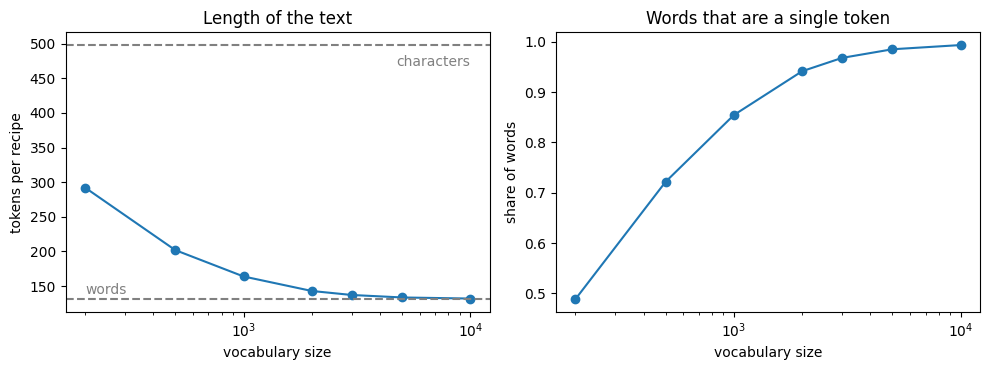

In [92]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 3.8))

ax[0].plot(stats.index, stats["tokens per recipe"], marker="o")
ax[0].axhline(words_per_recipe, color="gray", linestyle="--")
ax[0].axhline(chars_per_recipe, color="gray", linestyle="--")
ax[0].text(stats.index[0], words_per_recipe + 8, "words", color="gray")
ax[0].text(stats.index[-1], chars_per_recipe - 30, "characters", color="gray", ha="right")
ax[0].set_xscale("log")
ax[0].set_xlabel("vocabulary size")
ax[0].set_ylabel("tokens per recipe")
ax[0].set_title("Length of the text")

ax[1].plot(stats.index, stats["words as a single token"], marker="o")
ax[1].set_xscale("log")
ax[1].set_xlabel("vocabulary size")
ax[1].set_ylabel("share of words")
ax[1].set_title("Words that are a single token")

plt.tight_layout()
plt.show()

This is the trade-off that we found in the first notebook, but now we can choose where to stand. With 200 tokens a recipe is 292 tokens long on average: more than twice the length in words (131), and about 60% of the length in characters (498). With 1,000 tokens it is 164 tokens, 25% longer than in words; with 5,000 tokens, only 2% longer. The curve drops quickly at first and then flattens: each new token is a rarer piece, and it saves fewer and fewer tokens. The plot on the right tells the same story: with 1,000 tokens 85% of the words are already a single token, with 5,000 tokens 98.5%. Unknown tokens are practically absent at every size (they are only rare characters).

### The same vocabulary size, with and without subwords

Finally, let's compare the two approaches at the **same size** of the vocabulary. With the rule-based tokenizer, a vocabulary is obtained by keeping the words that occur at least $k$ times, and all the others are unknown. With $k = 10$ we obtain a vocabulary of a few thousand words. We train BPE with a vocabulary of the same size.

In [93]:
from collections import Counter

word_counts = Counter(w for t in train for w in pretokenizer.pretokenize(t))
test_words = [w for t in test for w in pretokenizer.pretokenize(t)]

word_vocab = {w for w, c in word_counts.items() if c >= 10}
bpe_same = BPETokenizer(vocab_size=len(word_vocab) + 1).fit(train)
bpe_tokens = [t for ws in (bpe_same.tokenize_words(x) for x in test) for w in ws for t in w]

pd.DataFrame({
    "vocabulary size": [len(word_vocab) + 1, len(bpe_same.vocab)],
    "tokens per recipe": [len(test_words) / len(test), len(bpe_tokens) / len(test)],
    "unknown tokens": [np.mean([w not in word_vocab for w in test_words]),
                       np.mean([t == bpe_same.unk_token for t in bpe_tokens])],
}, index=["words (min count 10)", "BPE"]).style.format(
    {"tokens per recipe": "{:.1f}", "unknown tokens": "{:.3%}"})

,vocabulary size,tokens per recipe,unknown tokens
words (min count 10),2760,130.8,1.857%
BPE,2760,138.1,0.004%


With the same vocabulary size (2,760 tokens), the rule-based tokenizer replaces 1.9% of the tokens of the test set with the unknown token, and it loses the information that they carried. BPE has practically no unknown tokens (0.004%, just rare characters), and it pays with about 6% more tokens per recipe (138 instead of 131). The size of the vocabulary and the length of the sequences are the two things that we have to balance, and with a statistical tokenizer we have a knob to do it.

### Take-away

- Tokenizing means choosing the unit in which text is written. Whole documents and single characters are the two extreme choices; the token sits in between.
- **Rule-based** tokenizers (NLTK, spaCy) apply linguistic knowledge that is written by hand for a language and a domain, and they produce a vocabulary of words that is closed and that we cannot control.
- **Statistical** tokenizers (BPE, WordPiece) learn the vocabulary from a corpus. The size of the vocabulary is a parameter, and it decides the trade-off between the size of the vocabulary and the length of the sequences. No word is unknown.
- Once a text is a sequence of tokens from a vocabulary, we can start turning it into numbers.